In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
import os



In [2]:


import zipfile

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Extract the zip file if needed
zip_path = "fr-tr.txt.zip"
extract_dir = "dataset"

if not os.path.exists(extract_dir):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete!")
else:
    print(f"Dataset directory '{extract_dir}' already exists.")

# Find the data files in the extracted directory
print("\nLooking for data files...")
data_files = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        full_path = os.path.join(root, file)
        data_files.append(full_path)
        print(f"Found: {full_path}")

# Load the parallel corpus files
# Look for files ending with .fr and .tr
french_file = None
turkish_file = None

for file in data_files:
    if file.endswith('.fr') or file.endswith('.FR'):
        french_file = file
        print(f"\n✓ French file identified: {file}")
    elif file.endswith('.tr') or file.endswith('.TR'):
        turkish_file = file
        print(f"✓ Turkish file identified: {file}")

# If still not found, look for files with language codes in the name
if not french_file or not turkish_file:
    print("\nSearching by filename pattern...")
    for file in data_files:
        filename = os.path.basename(file).lower()
        if 'fr-tr.fr' in filename or 'fr.tr.fr' in filename:
            french_file = file
            print(f"✓ French file found: {file}")
        elif 'fr-tr.tr' in filename or 'fr.tr.tr' in filename:
            turkish_file = file
            print(f"✓ Turkish file found: {file}")

if not french_file or not turkish_file:
    raise FileNotFoundError(
        f"Could not find parallel corpus files!\n"
        f"French file: {french_file}\n"
        f"Turkish file: {turkish_file}\n"
        f"Available files: {data_files}"
    )

# Load the data
print(f"\nLoading French sentences from: {french_file}")
with open(french_file, 'r', encoding='utf-8') as f:
    french_sentences = [line.strip() for line in f if line.strip()]

print(f"Loading Turkish sentences from: {turkish_file}")
with open(turkish_file, 'r', encoding='utf-8') as f:
    turkish_sentences = [line.strip() for line in f if line.strip()]

# Create a DataFrame
print(f"\nTotal French sentences: {len(french_sentences)}")
print(f"Total Turkish sentences: {len(turkish_sentences)}")

# Make sure both have the same length
min_len = min(len(french_sentences), len(turkish_sentences))
combined_df = pd.DataFrame({
    'french': french_sentences[:min_len],
    'turkish': turkish_sentences[:min_len]
})

print(f"\nCombined dataset size: {len(combined_df)}")

# Custom split: 80% train, 10% validation, 10% test
# (You can adjust these ratios)
print("\nCreating custom train/val/test split (80/10/10)...")
train_custom, temp = train_test_split(combined_df, test_size=0.2, random_state=42)
val_custom, test_custom = train_test_split(temp, test_size=0.5, random_state=42)

print(f"\nCustom split sizes:")
print(f"Train: {len(train_custom)}")
print(f"Validation: {len(val_custom)}")
print(f"Test: {len(test_custom)}")

# Save the splits
print("\nSaving data splits...")
os.makedirs('data', exist_ok=True)
train_custom.to_csv('data/train.csv', index=False)
val_custom.to_csv('data/val.csv', index=False)
test_custom.to_csv('data/test.csv', index=False)

print("Data saved to 'data/' directory")

Extracting fr-tr.txt.zip...
Extraction complete!

Looking for data files...
Found: dataset/README
Found: dataset/TED2020.fr-tr.tr
Found: dataset/LICENSE
Found: dataset/TED2020.fr-tr.xml
Found: dataset/TED2020.fr-tr.fr
✓ Turkish file identified: dataset/TED2020.fr-tr.tr

✓ French file identified: dataset/TED2020.fr-tr.fr

Loading French sentences from: dataset/TED2020.fr-tr.fr
Loading Turkish sentences from: dataset/TED2020.fr-tr.tr

Total French sentences: 368006
Total Turkish sentences: 368006

Combined dataset size: 368006

Creating custom train/val/test split (80/10/10)...

Custom split sizes:
Train: 294404
Validation: 36801
Test: 36801

Saving data splits...
Data saved to 'data/' directory


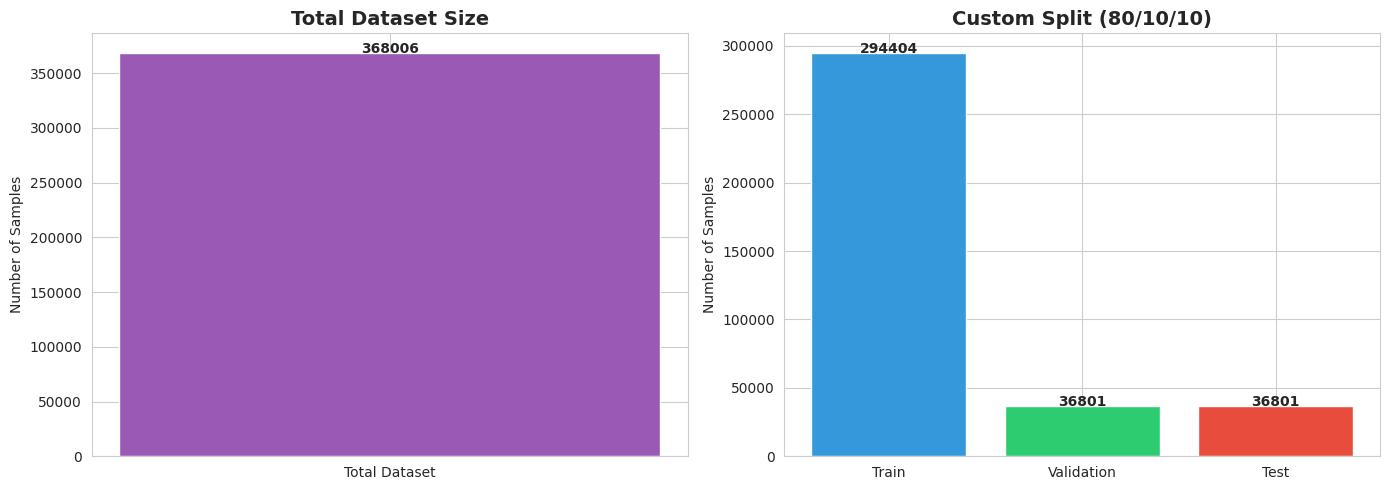

/tmp/ipython-input-54939599.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([fr_train.dropna(), tr_train.dropna()], labels=['French', 'Turkish'])


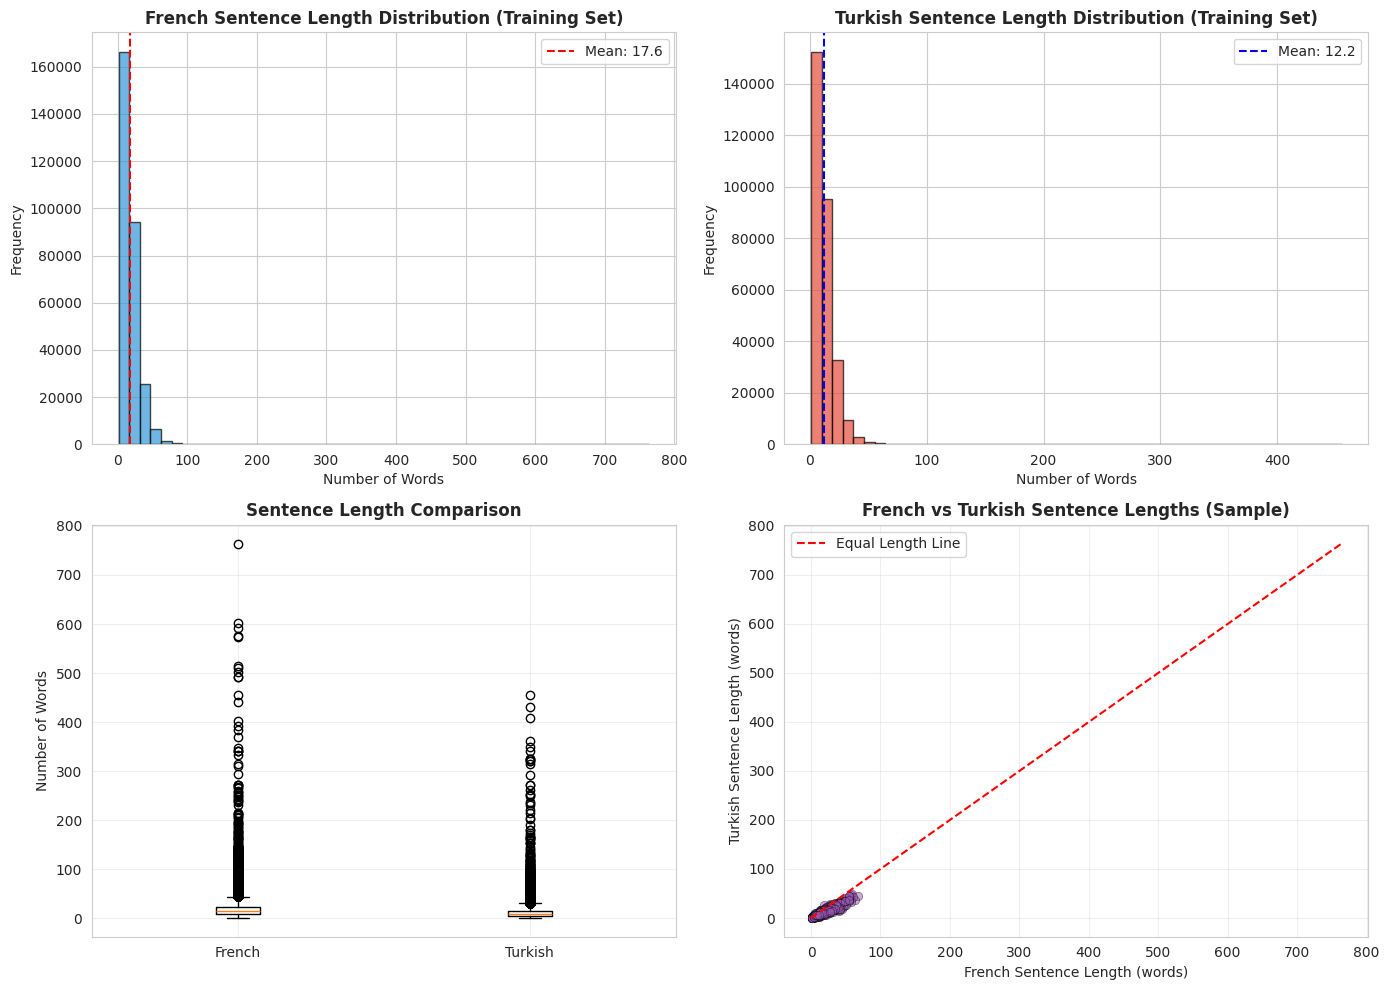

In [3]:
# 1. Dataset size comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total dataset
axes[0].bar(['Total Dataset'], [len(combined_df)], color='#9b59b6')
axes[0].set_title('Total Dataset Size', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].text(0, len(combined_df) + 50, str(len(combined_df)), ha='center', fontweight='bold')

# Custom split
sizes_custom = [len(train_custom), len(val_custom), len(test_custom)]
axes[1].bar(['Train', 'Validation', 'Test'], sizes_custom, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1].set_title('Custom Split (80/10/10)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
for i, v in enumerate(sizes_custom):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/split_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Sentence length distribution
def get_word_counts(df):
    fr_lengths = df['french'].str.split().str.len()
    tr_lengths = df['turkish'].str.split().str.len()
    return fr_lengths, tr_lengths

fr_train, tr_train = get_word_counts(train_custom)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# French length distribution
axes[0, 0].hist(fr_train, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('French Sentence Length Distribution (Training Set)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Words')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(fr_train.mean(), color='red', linestyle='--', label=f'Mean: {fr_train.mean():.1f}')
axes[0, 0].legend()

# Turkish length distribution
axes[0, 1].hist(tr_train, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Turkish Sentence Length Distribution (Training Set)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Words')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(tr_train.mean(), color='blue', linestyle='--', label=f'Mean: {tr_train.mean():.1f}')
axes[0, 1].legend()

# Length comparison boxplot
length_data = pd.DataFrame({
    'French': fr_train,
    'Turkish': tr_train
})
axes[1, 0].boxplot([fr_train.dropna(), tr_train.dropna()], labels=['French', 'Turkish'])
axes[1, 0].set_title('Sentence Length Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Words')
axes[1, 0].grid(True, alpha=0.3)

# Scatter plot: French vs Turkish lengths
sample_indices = np.random.choice(len(fr_train), min(1000, len(fr_train)), replace=False)
axes[1, 1].scatter(fr_train.iloc[sample_indices], tr_train.iloc[sample_indices],
                   alpha=0.5, c='#9b59b6', edgecolors='black', linewidth=0.5)
axes[1, 1].plot([0, max(fr_train.max(), tr_train.max())],
                [0, max(fr_train.max(), tr_train.max())],
                'r--', label='Equal Length Line')
axes[1, 1].set_title('French vs Turkish Sentence Lengths (Sample)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('French Sentence Length (words)')
axes[1, 1].set_ylabel('Turkish Sentence Length (words)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:

# 3. Statistics summary
print("\n" + "="*50)
print("DATASET STATISTICS")
print("="*50)
print(f"\nFrench sentences:")
print(f"  Mean length: {fr_train.mean():.2f} words")
print(f"  Median length: {fr_train.median():.2f} words")
print(f"  Min length: {fr_train.min()} words")
print(f"  Max length: {fr_train.max()} words")
print(f"  Std deviation: {fr_train.std():.2f} words")

print(f"\nTurkish sentences:")
print(f"  Mean length: {tr_train.mean():.2f} words")
print(f"  Median length: {tr_train.median():.2f} words")
print(f"  Min length: {tr_train.min()} words")
print(f"  Max length: {tr_train.max()} words")
print(f"  Std deviation: {tr_train.std():.2f} words")

# 4. Sample sentences
print("\n" + "="*50)
print("SAMPLE TRANSLATIONS")
print("="*50)
for i in range(20):
    print(f"\n[{i+1}]")
    print(f"FR: {train_custom.iloc[i]['french']}")
    print(f"TR: {train_custom.iloc[i]['turkish']}")

print("\n" + "="*50)
print("SETUP COMPLETE!")
print("="*50)
print("\nFiles saved:")
print("  - data/train.csv")
print("  - data/val.csv")
print("  - data/test.csv")
print("  - data/split_comparison.png")
print("  - data/length_analysis.png")
print("\nReady to proceed with model testing and training!")


DATASET STATISTICS

French sentences:
  Mean length: 17.57 words
  Median length: 15.00 words
  Min length: 1 words
  Max length: 764 words
  Std deviation: 13.04 words

Turkish sentences:
  Mean length: 12.23 words
  Median length: 10.00 words
  Min length: 1 words
  Max length: 455 words
  Std deviation: 8.96 words

SAMPLE TRANSLATIONS

[1]
FR: C'est en fait le cœur de vos compétences.
TR: Birçok yönden, bu neredeyse temel yetkinlik alanı.

[2]
FR: Il y a déjà de longues listes d'attente pour les maisons de repos.
TR: Bakımevlerinde bekleme listelerinin olduğunu biliyoruz.

[3]
FR: Le pouvoir peut également être une somme positive, où ton profit peut être mon profit.
TR: Güç bazen de olumlu kardır. senin kazancın benim kazancım olduğu yer.

[4]
FR: Voilà la taille microscopique des mouvements extraits par la simple observation de la lumière sur les objets, et est enregistrée par nos caméras.
TR: İşte nesnelerden yansıyan ve kameralarımızın kaydettiği ışığı gözlemleyerek elde ettiğim